<a href="https://colab.research.google.com/github/LIBY70/-goinhwal/blob/Hw/hw3_22012167_%EB%85%B8%EC%A3%BC%ED%98%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier

data = pd.read_csv('/content/titanic.csv')
data.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Embarked,Survived
0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,S,0
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,C,1
2,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,S,1
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,S,1
4,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,S,0


In [20]:
data = data.drop(['Name', 'Ticket'], axis=1)
data.isna().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Embarked,0
Survived,0


In [21]:
data.head()

,Pclass,Sex,Age,SibSp,Parch,Embarked,Survived
0,3,male,22.0,1,0,S,0
1,1,female,38.0,1,0,C,1
2,3,female,26.0,0,0,S,1
3,1,female,35.0,1,0,S,1
4,3,male,35.0,0,0,S,0


In [22]:
data['family'] = data['SibSp'] + data['Parch'] #family라는 데이터 새로 생성
data.drop(['SibSp', 'Parch'], axis=1, inplace=True)

In [23]:
data.head()

,Pclass,Sex,Age,Embarked,Survived,family
0,3,male,22.0,S,0,1
1,1,female,38.0,C,1,1
2,3,female,26.0,S,1,0
3,1,female,35.0,S,1,1
4,3,male,35.0,S,0,0


In [24]:
pd.get_dummies(data, columns = ['Sex', 'Embarked'], drop_first = True)

,Pclass,Age,Survived,family,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,0,1,True,False,True
1,1,38.0,1,1,False,False,False
2,3,26.0,1,0,False,False,True
3,1,35.0,1,1,False,False,True
4,3,35.0,0,0,True,False,True
...,...,...,...,...,...,...,...
884,2,27.0,0,0,True,False,True
885,1,19.0,1,0,False,False,True
886,3,28.0,0,3,False,False,True
887,1,26.0,1,0,True,False,False


In [25]:
data = pd.get_dummies(data, columns = ['Sex', 'Embarked'], drop_first = True)

In [26]:
data.head()

,Pclass,Age,Survived,family,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,0,1,True,False,True
1,1,38.0,1,1,False,False,False
2,3,26.0,1,0,False,False,True
3,1,35.0,1,1,False,False,True
4,3,35.0,0,0,True,False,True


In [27]:
from sklearn.model_selection import train_test_split
X = data.drop('Survived', axis=1)   #survived를 제외하여 X에 저장
y = data['Survived']                #survived 데이터만 y에 저장
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 100)

<로지스틱 회귀모델>

In [28]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [29]:
pred = model.predict(X_test)

In [30]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, pred) #생존과 사망을 79프로 맞췄다고 볼 수 있음.

0.7921348314606742

-> 로지스틱 회귀를 이용해 예측한 결과 약 79프로 맞춤.

<knn 모델>


In [31]:
from sklearn.preprocessing import StandardScaler
st_scaler = StandardScaler()      #스탠다드 스케일링
st_scaler.fit(X_train)            #스케일링은 학습셋으로 진행
X_train_scaled = st_scaler.transform(X_train)
X_test_scaled = st_scaler.transform(X_test)

In [32]:
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)
pred = knn.predict(X_test_scaled)

from sklearn.metrics import accuracy_score
accuracy_score(y_test, pred)   #예측값이 실제 값과 얼마나 같은지 보여줌.

0.8370786516853933

-> knn을 이용해 예측한 결과 약 84프로 맞춤.

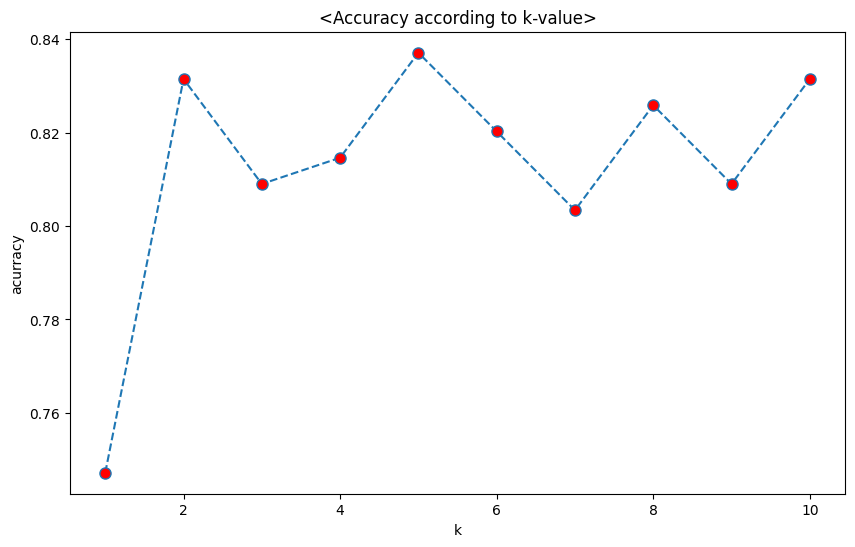

In [33]:
k_parm = range(1, 11)
test_acc_list =[]

for k in k_parm:   #k값을 포문을 이용해서 바꾸어 주고 각각 예측값 계산, 성능 측정 반복.
    knn=KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    pred=knn.predict(X_test_scaled)
    test_acc_list.append(accuracy_score(y_test, pred))

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), test_acc_list, marker='o', linestyle='dashed', markersize=8, markerfacecolor='red')
plt.title("<Accuracy according to k-value>")
plt.xlabel("k")
plt.ylabel("acurracy")
plt.show()


**<결과>**
- knn 모델의 성능이 로지스틱 회귀모델보다 더 높게 측정되었다. - (knn의 예측성능은 약 84퍼센트이고, 로지스틱 회귀모델의 예측성능은 79퍼센트임)
- knn 모델에서 k값을 1부터 10까지 변경하며 정확도를 확인한 결과 k가 5일 때 예측성능이 가장 높은 것을 확인 할 수 있다.  